# BROAD-NESS for Python

## Get the data and explore them 


Your data are: 3559 sources, over 776 time points, 5 conditions: ['M1', 'NT1', 'NT2', 'NT3', 'NT4']
--------------------------------------------
Computing PCA on the mean over conditions :
--------------------------------------------


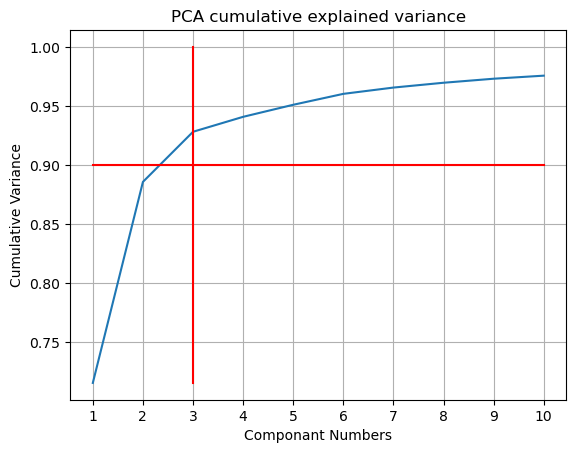

3 componant(s) account for 92.81 variance explained:
Componant 1 : 71.54 %
Componant 2 : 17.03 %
Componant 3 : 4.24 %
3 componant(s) will be used by default for the following analysis. Please change manually if needed.


In [3]:
from src.utils import load_data, data_overview, DATA_PATH
data_path = DATA_PATH + '/Data_Example.mat' # The data are teh mean across subjects and trials

conditions={'M1':0, 'NT1':1, 'NT2':2, 'NT3':3, 'NT4':4} # Dictionnary with conditions and names
data= load_data(data_path)
nb_compo = data_overview(data, conditions=conditions)

## Network estimation

In [4]:
from src.network_estimation import NetworkEstimator

estimator = NetworkEstimator(n_components=5, method="pca", conditions=conditions)

# Fit the estimator 
estimator.fit(data)

# You can threshold the componants 
thr_compo = estimator.threshold_components()

# Once the estimator is fit you can access the componants (nb_PC, nb_sources)
print(f'The commponants are : {estimator.components_.shape[0]} PCs, {estimator.components_.shape[1]} sources')

The commponants are : 5 PCs, 3559 sources


In [5]:
# Get the results 
result = estimator.fit_transform(data)

# With the results you can access to :
#result.components
#result.explained_variance
#result.timecourses["M1"] # Select the right condition that you are interested in!
#result.reconstructed_activity["M1"]

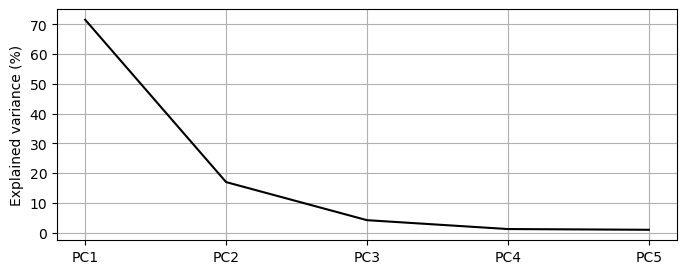

In [6]:
# Get here the plot of the variance
result.plot_variance()

In [7]:
# You can transform componant into a nifti image
img = result.get_nifti_component(n_compo=1, save=True)

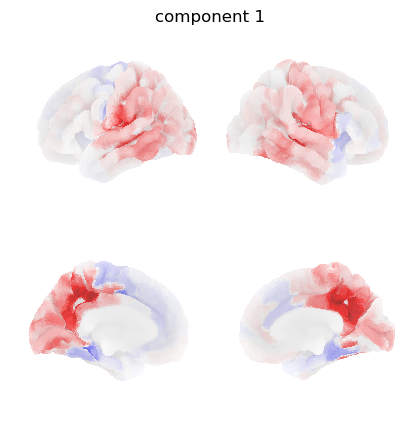

In [ ]:
# Once that you have the result you can plot them or interact
#fig, axs = result.plot_components(n_compo=1) # 45s to get the static
result.plot_components_interactive(n_compo=1) 

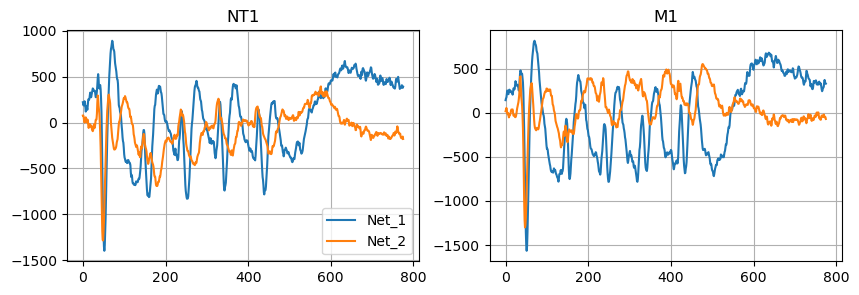

In [9]:
# Then access to the time course of your componants : grouby conditions or components
result.plot_timecourses(groupby='conditions', condition_to_plot=['M1', 'NT1'], time_course_to_plot=[1, 2], save=True)

In [10]:
# Finally you can run statistical analysis on the componants
from src.utils import compute_significant_pcs
significant_pcs = compute_significant_pcs(data[:, :, 1], result.explained_variance, permutations_num=10, randomization=3, summary=True)

Computing PCA on randomized data...
Randomization on Space and Time dimention
Variance explained by significant PCs (brain networks):
[0.7153759  0.17030123 0.04244439 0.01266619 0.01020578]


## Gradiant Analysis

--------------------------------------------
kmeans on 2 PCs
--------------------------------------------
Selecting the right number of components for K-means ...
With 4 cluster(s) we have a silhouette score of 0.48119041323661804


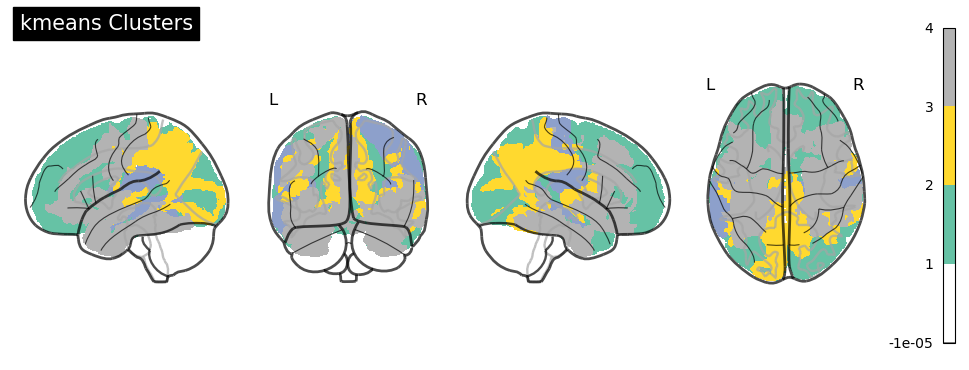

In [11]:
from src.gradient import clustering

result_clustering= clustering(result.components[:2, :])
result_clustering.plot_clusters_brain(save_fig=True)


## RQA analysis

In [12]:
from src.rqa import compute_rqa
import numpy as np

res = compute_rqa(result.timecourses, time=np.arange(0, len(result.timecourses['M1'])), conditions=conditions, nb_compo=1)

--------------------------------------------
Phase Space RQA on pca with 1 PCs
--------------------------------------------
Condition :  M1
Condition :  NT1
Condition :  NT2
Condition :  NT3
Condition :  NT4


KeyboardInterrupt: 

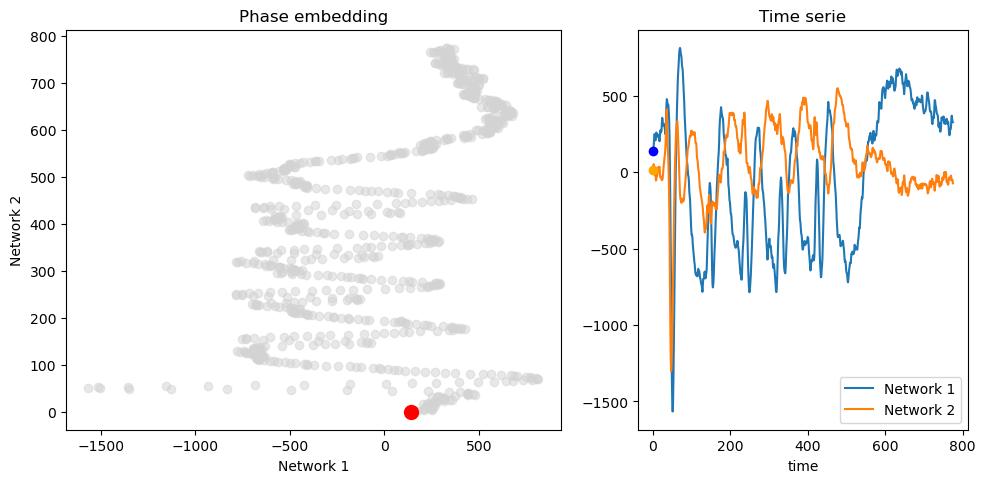

In [13]:
res.animate_phase_space('M1', save=True) # DOESN'T DO WHAT I WANT TODO

/Users/barbaragrosjean/Documents/MIB/broadness/src/rqa.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


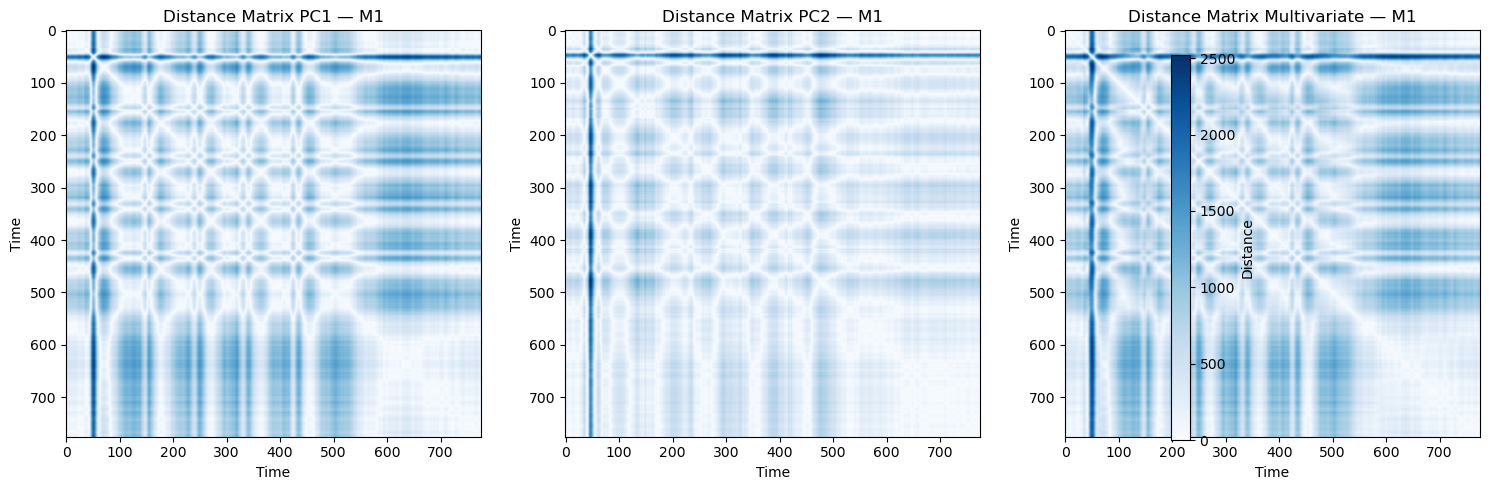

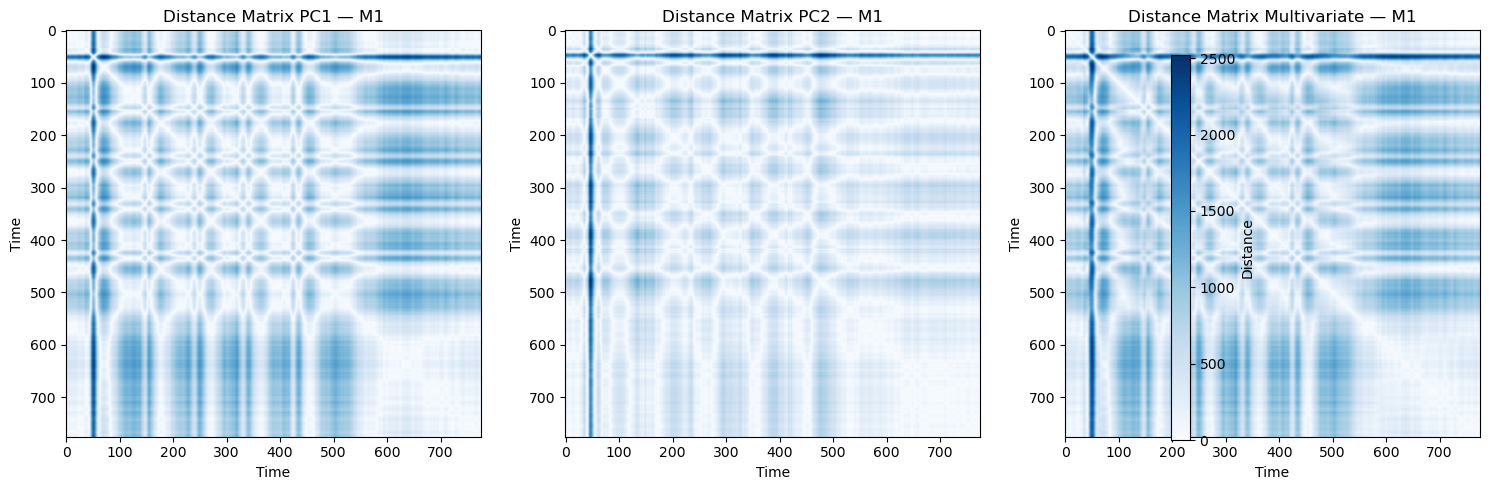

In [15]:
res.plot_recurrence('M1', save=True)